In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Load local file
df = pd.read_csv("VOO.csv")

C:\Users\josep\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
 #Standardize column names (important)
df.columns = [c.lower() for c in df.columns]

# Ensure date sorting
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Use close price safely
close = pd.to_numeric(df["close"], errors="coerce")

# Log returns
returns = 100 * np.log(close / close.shift(1))
returns = returns.dropna()

# Fit GARCH(1,1)
model = arch_model(returns, vol="Garch", p=1, q=1)
res = model.fit(disp="off")

print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -305.402
Distribution:                  Normal   AIC:                           618.803
Method:            Maximum Likelihood   BIC:                           632.905
                                        No. Observations:                  251
Date:                Sat, May 09 2026   Df Residuals:                      250
Time:                        11:12:28   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0773  4.612e-02      1.676  9.378e-02 [-1.31

C:\Users\josep\anaconda3\lib\site-packages\arch\__future__\_utility.py:11: FutureWarning: 
The default for reindex is True. After September 2021 this will change to
False. Set reindex to True or False to silence this message. Alternatively,
you can use the import comment

from arch.__future__ import reindexing

to globally set reindex to True and silence this warning.

  warnings.warn(


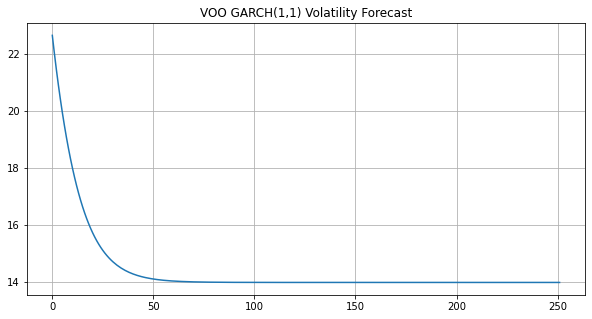

Annualized volatility: 13.98%


In [3]:
# Forecast 1 year (252 trading days)
forecast = res.forecast(horizon=252)

var = forecast.variance.iloc[-1]
vol = np.sqrt(var)
annual = vol * np.sqrt(252)

# Plot
plt.figure(figsize=(10,5))
plt.plot(annual.values)
plt.title("VOO GARCH(1,1) Volatility Forecast")
plt.grid()
plt.show()

print(f"Annualized volatility: {annual.iloc[-1]:.2f}%")

C:\Users\josep\anaconda3\lib\site-packages\arch\__future__\_utility.py:11: FutureWarning: 
The default for reindex is True. After September 2021 this will change to
False. Set reindex to True or False to silence this message. Alternatively,
you can use the import comment

from arch.__future__ import reindexing

to globally set reindex to True and silence this warning.

  warnings.warn(


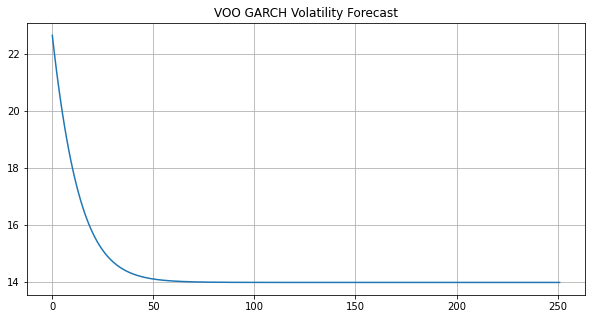

Final annualized volatility: 13.98%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# returns must already exist from your dataset step
# (if not, tell me and I’ll rebuild that too)

# 1. Fit model
model = arch_model(returns, vol="Garch", p=1, q=1)
results = model.fit(disp="off")

# 2. Forecast
forecast = results.forecast(horizon=252)

# 3. Extract variance
variance = forecast.variance.iloc[-1]

# 4. Convert to volatility
volatility = np.sqrt(variance)

# 5. Annualize
annualized = volatility * np.sqrt(252)

# 6. Plot
plt.figure(figsize=(10,5))
plt.plot(annualized.values)
plt.title("VOO GARCH Volatility Forecast")
plt.grid(True)
plt.show()


print(f"Final annualized volatility: {annualized.iloc[-1]:.2f}%")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4996.97
Distribution:                  Normal   AIC:                           10001.9
Method:            Maximum Likelihood   BIC:                           10027.0
                                        No. Observations:                 3935
Date:                Sat, May 09 2026   Df Residuals:                     3934
Time:                        15:16:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0860  1.181e-02      7.285  3.223e-13 [6.288e-0

C:\Users\josep\anaconda3\lib\site-packages\arch\__future__\_utility.py:11: FutureWarning: 
The default for reindex is True. After September 2021 this will change to
False. Set reindex to True or False to silence this message. Alternatively,
you can use the import comment

from arch.__future__ import reindexing

to globally set reindex to True and silence this warning.

  warnings.warn(


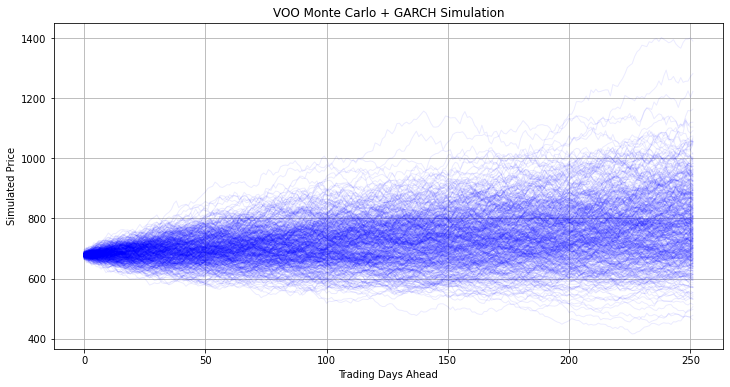


1-Year Forecast Summary
Current Price: $678.04
Median Forecast: $768.70
5th Percentile: $600.83
95th Percentile: $997.00


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# -------------------------------------------------
# LOAD YOUR LOCAL CSV
# -------------------------------------------------
# Replace with your own file path if needed
df = pd.read_csv(
    r"C:\Users\josep\Downloads\VOO.csv"
)

# Standardize columns
df.columns = [c.lower() for c in df.columns]

# Parse dates
df["date"] = pd.to_datetime(df["date"])

# Sort ascending
df = df.sort_values("date")

# Close prices
close = pd.to_numeric(df["close"], errors="coerce")

# -------------------------------------------------
# LOG RETURNS
# -------------------------------------------------
returns = np.log(close / close.shift(1)).dropna()


# Scale for GARCH stability
scaled_returns = returns * 100

# -------------------------------------------------
# FIT GARCH(1,1)
# -------------------------------------------------
model = arch_model(
    scaled_returns,
    vol="Garch",
    p=1,
    q=1,
    mean="Constant"
)

results = model.fit(disp="off")

print(results.summary())

# -------------------------------------------------
# FORECAST VOLATILITY
# -------------------------------------------------
forecast_horizon = 252

forecast = results.forecast(horizon=forecast_horizon)

variance = forecast.variance.iloc[-1].values

# Convert back from percent scaling
daily_vol = np.sqrt(variance) / 100


# -------------------------------------------------
# MONTE CARLO SIMULATION
# -------------------------------------------------
n_simulations = 500
n_days = 252

last_price = close.iloc[-1]

# Historical drift
mu = returns.mean()

simulations = np.zeros((n_days, n_simulations))

for sim in range(n_simulations):

    prices = [last_price]

    for day in range(n_days):

        shock = np.random.normal()

        drift = mu

        diffusion = daily_vol[day] * shock

        next_price = prices[-1] * np.exp(
            drift + diffusion
        )

        prices.append(next_price)
        
    simulations[:, sim] = prices[1:]

# -------------------------------------------------
# PLOT
# -------------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    simulations,
    linewidth=1,
    alpha=0.08,
    color="blue"
)


plt.title("VOO Monte Carlo + GARCH Simulation")
plt.xlabel("Trading Days Ahead")
plt.ylabel("Simulated Price")

plt.grid(True)

plt.show()

# -------------------------------------------------
# SUMMARY STATS
# -------------------------------------------------
final_prices = simulations[-1]

median_price = np.median(final_prices)

p5 = np.percentile(final_prices, 5)

p95 = np.percentile(final_prices, 95)

print("\n1-Year Forecast Summary")
print(f"Current Price: ${last_price:.2f}")
print(f"Median Forecast: ${median_price:.2f}")
print(f"5th Percentile: ${p5:.2f}")
print(f"95th Percentile: ${p95:.2f}")

In [19]:
# -------------------------------------------------
# VOO MONTE CARLO + GARCH + GEOPOLITICAL SHOCK
# STARTS FROM LATEST CLOSING PRICE
# -------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model


In [20]:
# -------------------------------------------------
# LOAD YOUR LOCAL CSV
# -------------------------------------------------
# Replace with your own file path if needed
df = pd.read_csv(
    r"C:\Users\josep\Downloads\VOO.csv"
)


In [21]:
# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Parse dates
df["date"] = pd.to_datetime(df["date"])

# Sort oldest -> newest
df = df.sort_values("date")

# Close prices
close = pd.to_numeric(
    df["close"],
    errors="coerce"
)

# -------------------------------------------------
# STARTING PRICE (LATEST CLOSE)
# -------------------------------------------------
start_price = close.iloc[-1]

print(f"\nStarting Price (Latest Close): ${start_price:.2f}")

# -------------------------------------------------
# LOG RETURNS
# -------------------------------------------------
returns = np.log(
    close / close.shift(1)
).dropna()

# Scale returns for GARCH stability
scaled_returns = returns * 100


Starting Price (Latest Close): $678.04


In [22]:
# -------------------------------------------------
# FIT GARCH MODEL
# -------------------------------------------------
model = arch_model(
    scaled_returns,
    p=1,
    q=1,
    vol="Garch",
    mean="Constant"
)

results = model.fit(disp="off")

print(results.summary())

# -------------------------------------------------
# FORECAST FUTURE VOLATILITY
# -------------------------------------------------
n_days = 252

forecast = results.forecast(horizon=n_days)

variance = forecast.variance.iloc[-1].values

# Convert back from percentage scaling
daily_vol = np.sqrt(variance) / 100

# -------------------------------------------------
# MONTE CARLO + SHOCK REGIME
# -------------------------------------------------
n_simulations = 500


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4996.97
Distribution:                  Normal   AIC:                           10001.9
Method:            Maximum Likelihood   BIC:                           10027.0
                                        No. Observations:                 3935
Date:                Sun, May 10 2026   Df Residuals:                     3934
Time:                        17:53:29   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0860  1.181e-02      7.285  3.223e-13 [6.288e-0

C:\Users\josep\anaconda3\lib\site-packages\arch\__future__\_utility.py:11: FutureWarning: 
The default for reindex is True. After September 2021 this will change to
False. Set reindex to True or False to silence this message. Alternatively,
you can use the import comment

from arch.__future__ import reindexing

to globally set reindex to True and silence this warning.

  warnings.warn(


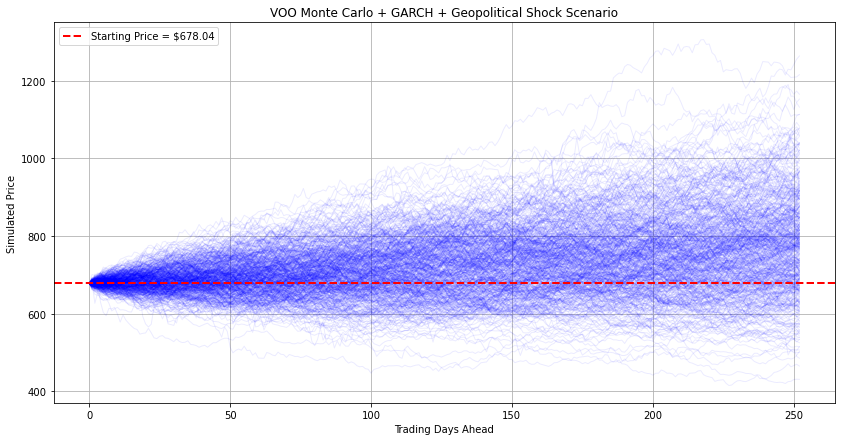


---------- 1 YEAR FORECAST ----------
Starting Price: $678.04
Median Forecast: $776.13
5th Percentile (Bear Scenario): $572.93
95th Percentile (Bull Scenario): $1020.67


In [27]:
simulations = np.zeros((n_days + 1, n_simulations))

# Explicitly set ALL paths to start at yesterday close
simulations[0] = start_price

# Historical drift
mu = returns.mean()

# -------------------------------------------------
# SHOCK SETTINGS
# -------------------------------------------------
shock_probability = 0.15       # 15% annual chance
shock_drop = -0.08             # -8% sudden drop
shock_vol_multiplier = 2.5     # volatility spike
shock_duration = 20            # trading days

# -------------------------------------------------
# RUN SIMULATIONS
# -------------------------------------------------
for sim in range(n_simulations):

    shock_triggered = False
    shock_end_day = 0

    for day in range(1, n_days + 1):

        current_vol = daily_vol[day - 1]

        # -----------------------------------------
        # RANDOM SHOCK EVENT
        # -----------------------------------------
        if (
            not shock_triggered
            and np.random.rand() < shock_probability / n_days
        ):
         
            shock_triggered = True
            shock_end_day = day + shock_duration

            # Immediate market drop
            simulations[day, sim] = (
                simulations[day - 1, sim]
                * (1 + shock_drop)
            )

            continue
            
               # -----------------------------------------
        # CRISIS VOLATILITY REGIME
        # -----------------------------------------
        if shock_triggered and day <= shock_end_day:
            current_vol *= shock_vol_multiplier

        # -----------------------------------------
        # NORMAL PRICE EVOLUTION
        # -----------------------------------------
        shock = np.random.normal()

        drift = mu

        diffusion = current_vol * shock

        simulations[day, sim] = (
            simulations[day - 1, sim]
            * np.exp(drift + diffusion)
        )

# -------------------------------------------------
# PLOT
# -------------------------------------------------
plt.figure(figsize=(14,7))

plt.plot(
    simulations,
    linewidth=1,
    alpha=0.08,
    color="blue"
)


# Starting price reference line
plt.axhline(
    start_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Starting Price = ${start_price:.2f}"
)

plt.title(
    "VOO Monte Carlo + GARCH + Geopolitical Shock Scenario"
)

plt.xlabel("Trading Days Ahead")

plt.ylabel("Simulated Price")

plt.legend()

plt.grid(True)

plt.show()

# -------------------------------------------------
# SUMMARY STATISTICS
# -------------------------------------------------
final_prices = simulations[-1]

median_price = np.median(final_prices)

p5 = np.percentile(final_prices, 5)

p95 = np.percentile(final_prices, 95)

print("\n---------- 1 YEAR FORECAST ----------")

print(f"Starting Price: ${start_price:.2f}")

print(f"Median Forecast: ${median_price:.2f}")

print(f"5th Percentile (Bear Scenario): ${p5:.2f}")

print(f"95th Percentile (Bull Scenario): ${p95:.2f}")